In [17]:
import calliope
import pandas as pd
from pathlib import Path

# Results are one folder up from notebooks/
results_dir = Path("../outputs")

files = {
    "without_transformer": results_dir / "without_transformer.nc",
    "with_transformer": results_dir / "with_transformer.nc",
    "grid_only": results_dir/"grid_only.nc"
}

models = {
    scenario: calliope.read_netcdf(path)
    for scenario, path in files.items()
}

In [18]:
def safe_sum(model, var_name, **selectors):
    """Safely sum a Calliope result variable."""
    if var_name not in model.results:
        return 0
    
    data = model.results[var_name]
    
    for dim, value in selectors.items():
        if dim in data.dims:
            data = data.sel({dim: value})
    
    return float(data.sum())


def safe_value(model, var_name, **selectors):
    """Safely get a single value from a Calliope result variable."""
    if var_name not in model.results:
        return 0
    
    data = model.results[var_name]
    
    for dim, value in selectors.items():
        if dim in data.dims:
            data = data.sel({dim: value})
    
    return float(data.sum())

In [19]:
# Use one model as the source of input assumptions
model = models["without_transformer"]

def get_param(model, var_name, tech):
    if var_name not in model.inputs:
        return None
    
    data = model.inputs[var_name]
    
    if "techs" in data.dims:
        data = data.sel(techs=tech)
    
    try:
        return float(data.sum())
    except Exception:
        return None


technologies = ["pv", "battery", "supply_grid_power"]

rows = []

for tech in technologies:
    rows.append({
        "Technology": tech,
        "Capex (Power) [MXN/kW]": get_param(model, "cost_flow_cap", tech),
        "Capex (Storage) [MXN/kWh]": get_param(model, "cost_storage_cap", tech),
        "Grid Price / Opex [MXN/kWh]": get_param(model, "cost_flow_in", tech),
        "Area per Capacity [m²/kW]": get_param(model, "area_use_per_flow_cap", tech),
        "Max Area [m²]": get_param(model, "area_use_max", tech),
        "Max Power Capacity [kW]": get_param(model, "flow_cap_max", tech),
        "Max Storage Capacity [kWh]": get_param(model, "storage_cap_max", tech),
        "Charging Efficiency [-]": get_param(model, "flow_out_eff", tech),
        "Discharging Efficiency [-]": get_param(model, "flow_in_eff", tech),
        "Storage Loss [-]": get_param(model, "storage_loss", tech),
        "Lifetime [years]": get_param(model, "lifetime", tech),
    })

inputs_table = pd.DataFrame(rows)

inputs_table

,Technology,Capex (Power) [MXN/kW],Capex (Storage) [MXN/kWh],Grid Price / Opex [MXN/kWh],Area per Capacity [m²/kW],Max Area [m²],Max Power Capacity [kW],Max Storage Capacity [kWh],Charging Efficiency [-],Discharging Efficiency [-],Storage Loss [-],Lifetime [years]
0,pv,700.0,0.0,0.00,7.0,7627.0,999.0,0.0,0.00,0.00,0.00,25.0
1,battery,160.0,230.0,0.00,0.0,0.0,inf,inf,0.95,0.95,0.01,20.0
2,supply_grid_power,0.0,0.0,0.32,0.0,0.0,165.0,0.0,0.00,0.00,0.00,0.0


In [20]:
rows = []

for scenario, model in models.items():

    pv_capacity_kw = safe_value(
        model, "flow_cap", techs="pv"
    )

    battery_power_capacity_kw = safe_value(
        model, "flow_cap", techs="battery"
    )

    battery_energy_capacity_kwh = safe_value(
        model, "storage_cap", techs="battery"
    )

    pv_area_m2 = safe_value(
        model, "area_use", techs="pv"
    )

    unmet_demand_kwh = safe_sum(
        model, "unmet_demand"
    ) 

    total_investment_cost = safe_sum(
        model, "cost_investment"
    )

    annualised_investment_cost = (
        safe_sum(model, "cost_investment_flow_cap")
        + safe_sum(model, "cost_investment_storage_cap")
        + safe_sum(model, "cost_investment_area_use")
    )

    variable_operating_cost = safe_sum(
        model, "cost_var"
    )

    total_cost_per_year = safe_sum(
        model, "cost"
    )

    total_demand_kwh = safe_sum(
        model, "flow_in", techs="demand_electricity"
    )

    total_levelised_cost = (
        total_cost_per_year / total_demand_kwh
        if total_demand_kwh != 0 else None
    )

    rows.append({
        "Scenario": scenario,
        "PV Capacity [kW]": pv_capacity_kw,
        "Battery Power Capacity [kW]": battery_power_capacity_kw,
        "Battery Energy Capacity [kWh]": battery_energy_capacity_kwh,
        "PV Area [m²]": pv_area_m2,
        "Unmet Demand [kWh/year]": unmet_demand_kwh,
        "Total Investment Cost [€]": total_investment_cost,
        "Total Cost [€/year]": total_cost_per_year,
        "Annualised Investment Cost [€/year]": annualised_investment_cost,
        "Variable Operating Cost [€/year]": variable_operating_cost,
        "Total Levelised Cost [€/kWh]": total_levelised_cost,
    })

comparison_table = pd.DataFrame(rows)

comparison_table

,Scenario,PV Capacity [kW],Battery Power Capacity [kW],Battery Energy Capacity [kWh],PV Area [m²],Unmet Demand [kWh/year],Total Investment Cost [€],Total Cost [€/year],Annualised Investment Cost [€/year],Variable Operating Cost [€/year],Total Levelised Cost [€/kWh]
0,without_transformer,431.509536,114.114675,478.443466,3020.566755,0.000000,430357.020638,64335.766518,430357.020638,0,0.180603
1,with_transformer,431.417325,114.075578,478.219079,3019.921276,0.000000,640234.608061,79235.504363,430234.608061,0,0.222430
2,grid_only,0.000000,0.000000,0.000000,0.000000,464.358691,0.000000,113844.138748,0.000000,0,0.319583


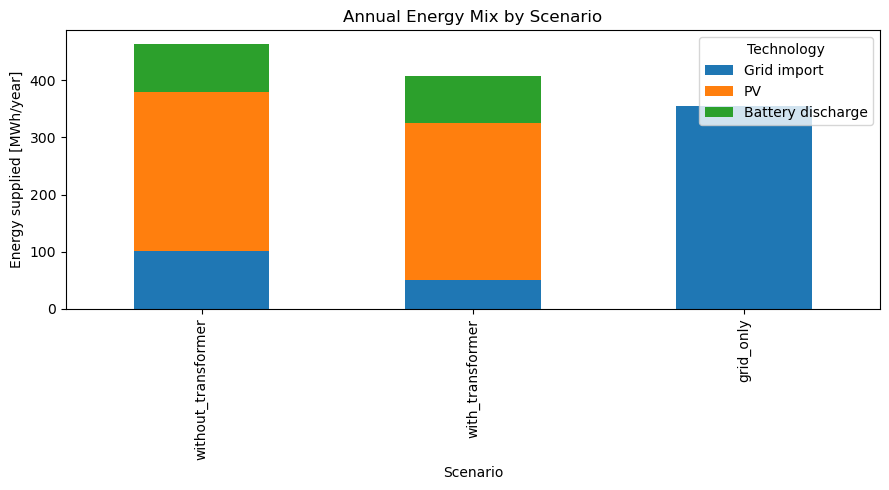

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

def get_energy_mix(model):
    mix = {}

    # Grid import
    mix["Grid import"] = safe_sum(model, "flow_out", techs="supply_grid_power")

    # PV generation
    mix["PV"] = safe_sum(model, "flow_out", techs="pv")

    # Battery discharge, if present
    mix["Battery discharge"] = safe_sum(model, "flow_out", techs="battery")

    return mix


energy_mix = pd.DataFrame({
    scenario: get_energy_mix(model)
    for scenario, model in models.items()
}).T

# Convert kWh to MWh for readability
energy_mix_mwh = energy_mix / 1000

energy_mix_mwh.plot(kind="bar", stacked=True, figsize=(9, 5))

plt.ylabel("Energy supplied [MWh/year]")
plt.xlabel("Scenario")
plt.title("Annual Energy Mix by Scenario")
plt.legend(title="Technology")
plt.tight_layout()
plt.show()

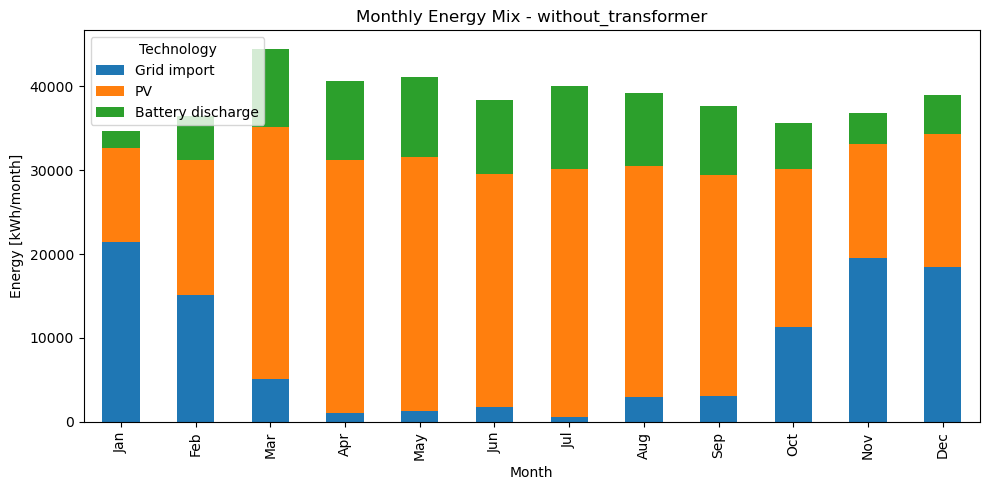

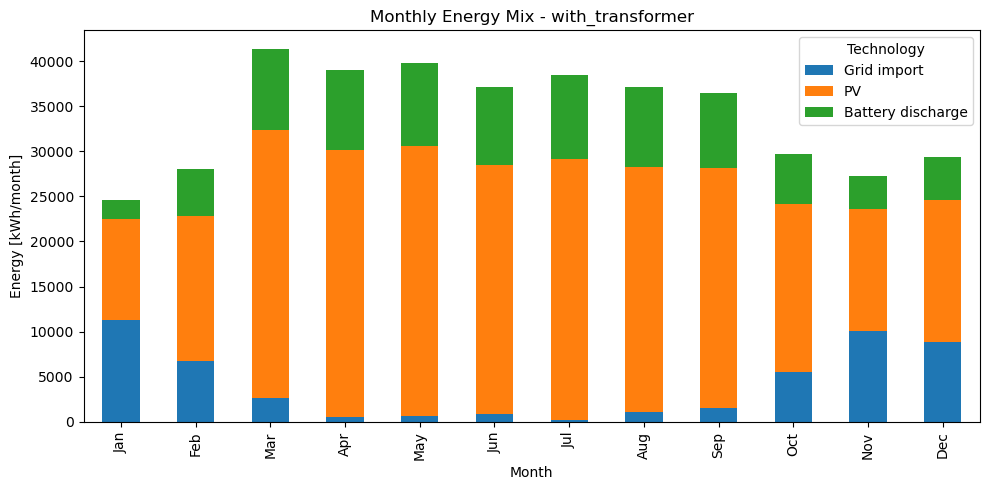

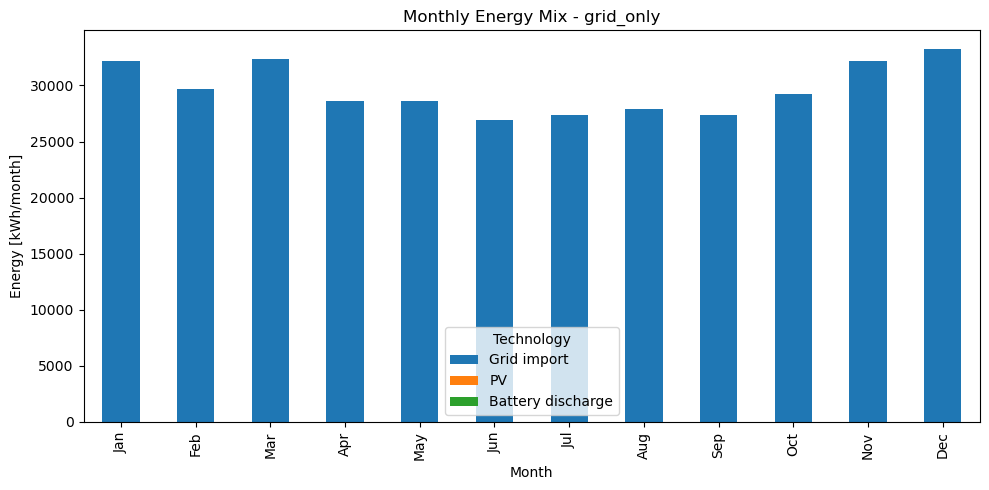

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

def get_tech_timeseries(model, tech):
    da = model.results.flow_out.sel(techs=tech)

    # Sum over all dimensions except timesteps
    dims_to_sum = [dim for dim in da.dims if dim != "timesteps"]
    if dims_to_sum:
        da = da.sum(dim=dims_to_sum)

    s = da.to_series()
    s.index = pd.to_datetime(s.index)

    return s


def monthly_energy_mix(model):
    data = pd.DataFrame()

    data["Grid import"] = get_tech_timeseries(model, "supply_grid_power")
    data["PV"] = get_tech_timeseries(model, "pv")

    if "battery" in model.results.techs.values:
        data["Battery discharge"] = get_tech_timeseries(model, "battery")

    monthly = data.resample("ME").sum()

    return monthly


for scenario, model in models.items():
    monthly_mix = monthly_energy_mix(model)

    monthly_mix.index = monthly_mix.index.strftime("%b")

    ax = monthly_mix.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 5)
    )

    plt.title(f"Monthly Energy Mix - {scenario}")
    plt.xlabel("Month")
    plt.ylabel("Energy [kWh/month]")
    plt.legend(title="Technology")
    plt.tight_layout()
    plt.show()

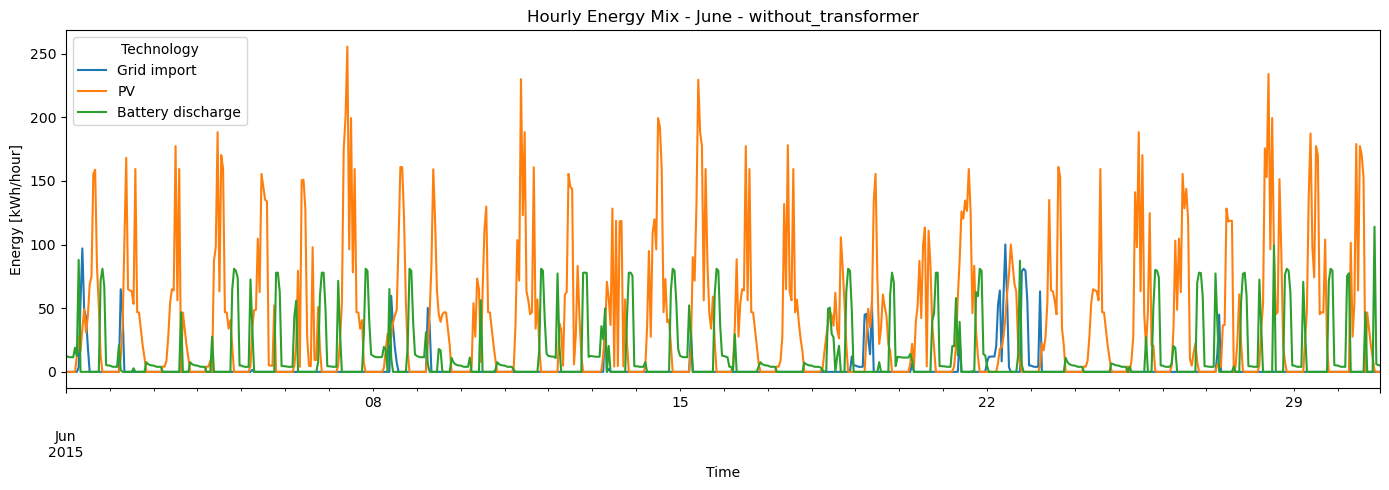

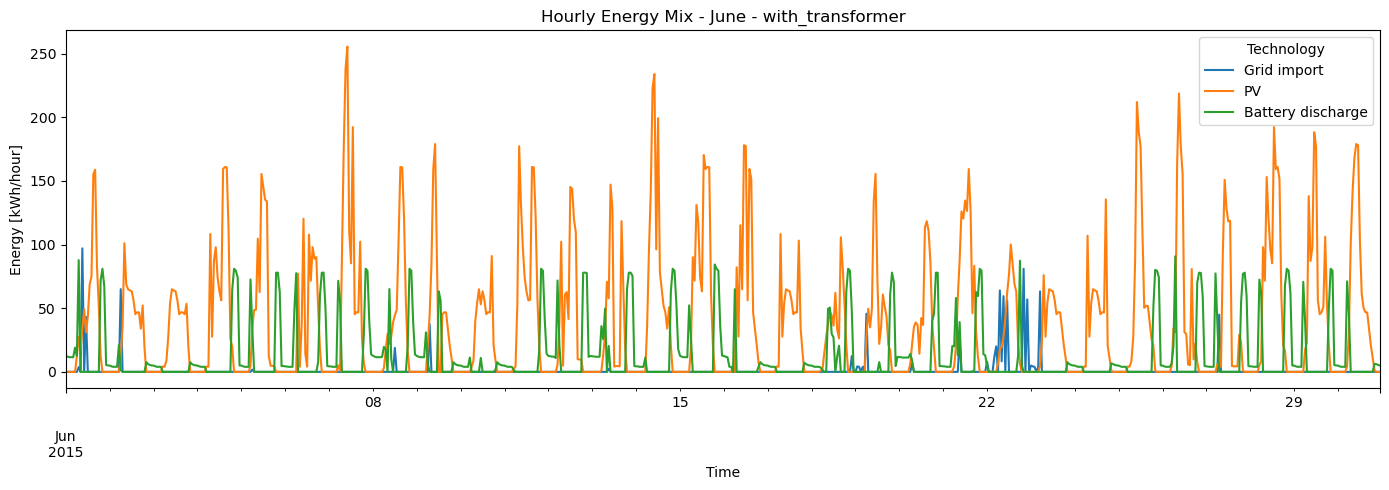

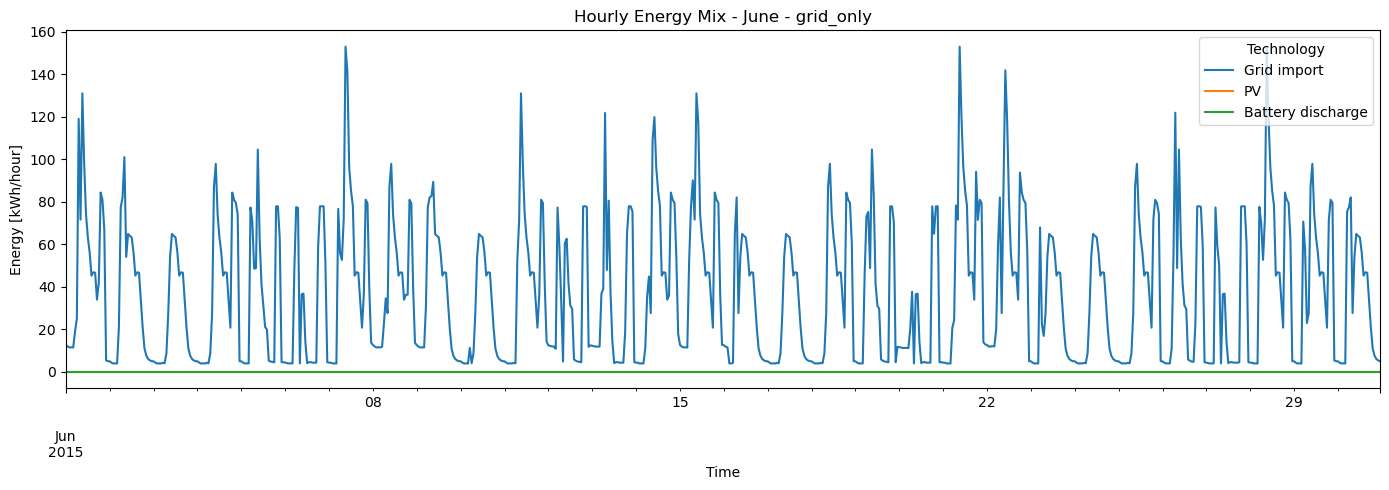

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

def get_tech_timeseries(model, tech):
    da = model.results.flow_out.sel(techs=tech)

    # Sum over all dimensions except timesteps
    dims_to_sum = [dim for dim in da.dims if dim != "timesteps"]
    if dims_to_sum:
        da = da.sum(dim=dims_to_sum)

    s = da.to_series()
    s.index = pd.to_datetime(s.index)

    return s


def hourly_energy_mix_june(model):
    data = pd.DataFrame()

    data["Grid import"] = get_tech_timeseries(model, "supply_grid_power")
    data["PV"] = get_tech_timeseries(model, "pv")

    if "battery" in model.results.techs.values:
        data["Battery discharge"] = get_tech_timeseries(model, "battery")

    # Keep only June
    june = data[data.index.month == 6]

    return june


for scenario, model in models.items():
    june_mix = hourly_energy_mix_june(model)

    ax = june_mix.plot(
        kind="line",
        figsize=(14, 5)
    )

    plt.title(f"Hourly Energy Mix - June - {scenario}")
    plt.xlabel("Time")
    plt.ylabel("Energy [kWh/hour]")
    plt.legend(title="Technology")
    plt.tight_layout()
    plt.show()

In [27]:
list(models["with_transformer"].results.data_vars)

['flow_cap',
 'flow_out',
 'flow_in',
 'flow_export',
 'area_use',
 'source_use',
 'source_cap',
 'storage_cap',
 'storage',
 'unmet_demand',
 'unused_supply',
 'purchased_units',
 'cost_investment_purchase',
 'flow_out_inc_eff',
 'flow_in_inc_eff',
 'cost_operation_variable',
 'cost_investment_flow_cap',
 'cost_investment_storage_cap',
 'cost_investment',
 'cost_investment_annualised',
 'cost',
 'min_cost_optimisation',
 'capacity_factor',
 'systemwide_capacity_factor',
 'systemwide_levelised_cost',
 'total_levelised_cost',
 'unmet_sum']